# Spaceship Titanic competition - Implementation by *Nikos Laloutsos*



In [1]:
import tensorflow as tf
import ydf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#model = ydf.RandomForestLearner(label="l").train(ds)

dataset_df = pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')
print("Full train dataset shape is {}".format(dataset_df.shape))
dataset_df.head(5)

2025-08-23 11:51:32.800356: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755949893.055092      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755949893.128792      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Full train dataset shape is (8693, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


Now we know that the data consists of 14 features and 8,693 columns.
We also check the first 5 rows of the dataset, so we can see in more detail how our data look like.


In [2]:
dataset_df.describe()



,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


# Handling missing values

The graph below indicates that each feature has around 200 missing values, which is relatively small compared to the overall dataset size. Therefore, the most appropriate approach is to fill the missing values with the mean of the respective feature. Before we do that, we will keep exploring the data set for further improvements and feature engineering.

<function matplotlib.pyplot.show(close=None, block=None)>

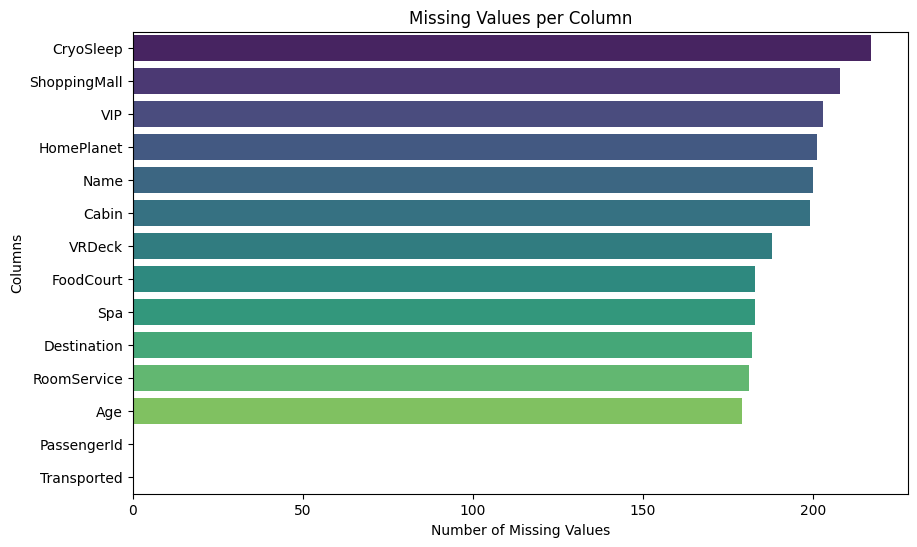

In [3]:
plt.figure(figsize=(10,6))
missing = dataset_df.isnull().sum().sort_values(ascending=False)
sns.barplot(x=missing.values, y=missing.index, palette="viridis")
plt.title("Missing Values per Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")
plt.show


# Type of data
Now we need to examine the data type of each feature in order to determine the most appropriate way to handle its missing values.

In [4]:
print(dataset_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None


# Feature engineering
Now that we have identified the type of each feature, we apply a preprocessing pipeline to transform and clean the dataset. This includes splitting the Cabin column, filling missing numeric and boolean values, converting booleans to integers, and handling categorical features. Finally, we verify that no missing values remain to ensure the dataset is ready for model training.

In [5]:
import pandas as pd

def preprocess_dataset(df):

    df = df.drop(['PassengerId', 'Name'], axis=1)

    # --- 0. Split Cabin into Deck, Cabin_num, Side ---
    if 'Cabin' in df.columns:
        df[['Deck', 'Cabin_num', 'Side']] = df['Cabin'].str.split("/", expand=True)
        df = df.drop('Cabin', axis=1)

    # --- 1. Numeric features (spending columns) ---
    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for col in spending_cols:
        df[f'{col}_missing'] = df[col].isnull().astype(int)
        df[col] = df[col].fillna(0)

    # --- 2. Numeric feature: Age ---
    df['Age_missing'] = df['Age'].isnull().astype(int)
    df['Age'] = df['Age'].fillna(df['Age'].median())

    # --- 3. Boolean features ---
    bool_cols = df.select_dtypes(include='bool').columns.tolist()
    for col in bool_cols:
        if df[col].isnull().sum() > 0:
            df[f'{col}_missing'] = df[col].isnull().astype(int)
        df[col] = df[col].fillna(False).astype(int)

    cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Name', 'Deck', 'Side']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].fillna("Unknown")
    if 'Cabin_num' in df.columns:
        df['Cabin_num_missing'] = df['Cabin_num'].isnull().astype(int)
    else:
        df['Cabin_num_missing'] = 0  

    label = "Transported"
    dataset_df[label] = dataset_df[label].astype(int)



    return df

# Apply preprocessing
dataset_df = preprocess_dataset(dataset_df)

# Check that no missing values remain
print(dataset_df.isnull().sum())
print("All good!")


HomePlanet                0
CryoSleep                 0
Destination               0
Age                       0
VIP                       0
RoomService               0
FoodCourt                 0
ShoppingMall              0
Spa                       0
VRDeck                    0
Transported               0
Deck                      0
Cabin_num               199
Side                      0
RoomService_missing       0
FoodCourt_missing         0
ShoppingMall_missing      0
Spa_missing               0
VRDeck_missing            0
Age_missing               0
Cabin_num_missing         0
dtype: int64
All good!


We now split the data set into training and validation set.

In [6]:
def split_dataset(dataset, test_ratio=0.20):
  test_indices = np.random.rand(len(dataset)) < test_ratio
  return dataset[~test_indices], dataset[test_indices]

train_ds_pd, valid_ds_pd = split_dataset(dataset_df)
print("{} examples in training, {} examples in testing.".format(
    len(train_ds_pd), len(valid_ds_pd)))

6986 examples in training, 1707 examples in testing.


# TF-DF compatibility
We apply further modifications so that our dataset can be used with TensorFlow Decision Forests (TF-DF).

In [7]:
import tensorflow_decision_forests as tfdf

# --- 1. Convert Boolean columns to integers (0/1) ---
bool_cols = ['CryoSleep', 'VIP']
for col in bool_cols:
    # Replace True with 1, False and "Unknown" with 0, then cast to int
    train_ds_pd.loc[:, col] = train_ds_pd[col].replace({True: 1, False: 0, "Unknown": 0}).astype(int)
    valid_ds_pd.loc[:, col] = valid_ds_pd[col].replace({True: 1, False: 0, "Unknown": 0}).astype(int)

# --- 2. Ensure categorical columns are strings and fill missing with "Unknown" ---
cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
for col in cat_cols:
    train_ds_pd.loc[:, col] = train_ds_pd[col].fillna("Unknown").astype(str)
    valid_ds_pd.loc[:, col] = valid_ds_pd[col].fillna("Unknown").astype(str)

# --- 3. Define the target label ---
label = "Transported"

# --- 4. Convert Pandas DataFrames to TensorFlow Decision Forests datasets ---
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_ds_pd, label=label)
valid_ds = tfdf.keras.pd_dataframe_to_tf_dataset(valid_ds_pd, label=label)

print("all good")

all good


/tmp/ipykernel_13/978276799.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_ds_pd.loc[:, col] = train_ds_pd[col].replace({True: 1, False: 0, "Unknown": 0}).astype(int)
/tmp/ipykernel_13/978276799.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  valid_ds_pd.loc[:, col] = valid_ds_pd[col].replace({True: 1, False: 0, "Unknown": 0}).astype(int)
/tmp/ipykernel_13/978276799.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly cal

# Defining the model
We choose to define and compile the following model without specifying hyperparameters, as our feature engineering is already strong.I will do further experimentation with hyperparameters in the future.

In [8]:
rf = tfdf.keras.RandomForestModel() 
rf.compile(metrics=["accuracy"])

Use /tmp/tmp63n2mgg2 as temporary training directory


# Training the model

In [9]:
rf.fit(x=train_ds, validation_data=valid_ds)

Reading training dataset...
Training dataset read in 0:00:04.110364. Found 6986 examples.
Reading validation dataset...
Num validation examples: tf.Tensor(1707, shape=(), dtype=int32)
Validation dataset read in 0:00:00.491093. Found 1707 examples.
Training model...


I0000 00:00:1755949918.386225      13 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1755949918.387058      13 kernel.cc:783] Collect training examples
I0000 00:00:1755949918.387080      13 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1755949918.387757      13 kernel.cc:401] Number of batches: 7
I0000 00:00:1755949918.387792      13 kernel.cc:402] Number of examples: 6986
I0000 00:00:1755949918.390936      13 data_spec_inference.cc:354] 1253 item(s) have been pruned (i.e. they are considered out of dictionary) for the column Cabin_num (500 item(s) left) because min_value_count=5 and max_number_of_unique_values=2000
I0000 00:00:

Model trained in 0:00:41.890813
Compiling model...


I0000 00:00:1755949960.164447      13 decision_forest.cc:761] Model loaded with 300 root(s), 230850 node(s), and 20 input feature(s).
I0000 00:00:1755949960.167716      13 abstract_model.cc:1404] Engine "RandomForestGeneric" built


Model compiled.


# Model structure 
To better understand how the model makes decisions, we use this code to visualize how the leaves branch out.

In [10]:
tfdf.model_plotter.plot_model_in_colab(rf, tree_idx=0, max_depth=3)

# Accuracy
We also visualize how accuracy changes while the model is being trained.

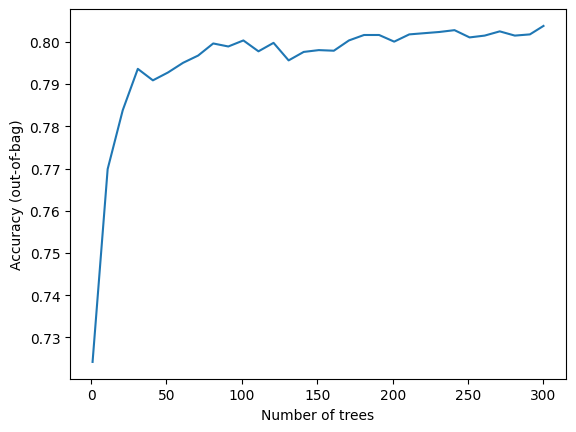

In [11]:
import matplotlib.pyplot as plt
logs = rf.make_inspector().training_logs()
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.show()

# Test set feature engineering 
Finally, we apply the same preprocessing steps to the test set so that the model can make predictions consistently with how it was trained.

In [12]:
# Load the test dataset
test_df = pd.read_csv('/kaggle/input/spaceship-titanic/test.csv')
submission_id = test_df.PassengerId

# --- 0. Split Cabin into Deck, Cabin_num, Side ---
if 'Cabin' in test_df.columns:
    test_df[['Deck', 'Cabin_num', 'Side']] = test_df['Cabin'].str.split("/", expand=True)
    test_df = test_df.drop('Cabin', axis=1)

# --- 1. Numeric features (spending columns) ---
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in spending_cols:
    test_df[f'{col}_missing'] = test_df[col].isnull().astype(int)
    test_df[col] = test_df[col].fillna(0)

# --- 2. Numeric feature: Age ---
test_df['Age_missing'] = test_df['Age'].isnull().astype(int)
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

# --- 3. Boolean features ---
bool_cols = ['CryoSleep', 'VIP']
for col in bool_cols:
    if col in test_df.columns:
        test_df[col] = test_df[col].map({True: 1, False: 0, "Unknown": 0}).fillna(0).astype(int)

# --- 4. Categorical features ---
cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
for col in cat_cols:
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna("Unknown").astype(str)

# --- 5. Cabin_num missing indicator ---
if 'Cabin_num' in test_df.columns:
    test_df['Cabin_num_missing'] = test_df['Cabin_num'].isnull().astype(int)
else:
    test_df['Cabin_num_missing'] = 0

print("Test dataset preprocessing done!")


Test dataset preprocessing done!


In [13]:
# --- 1. Convert Boolean columns to integers (0/1) ---
bool_cols = ['CryoSleep', 'VIP']
for col in bool_cols:
    if col in test_df.columns:
        test_df[col] = test_df[col].replace({True: 1, False: 0, "Unknown": 0}).astype(int)

# --- 2. Ensure categorical columns are strings and fill missing with "Unknown" ---
cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
for col in cat_cols:
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna("Unknown").astype(str)


# Prediction
The model now is being tested through the test set.

In [14]:
# Convert pd dataframe to tf dataset
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(test_df)

# Get the predictions for testdata
predictions = rf.predict(test_ds)
n_predictions = (predictions > 0.5).astype(bool)
output = pd.DataFrame({'PassengerId': submission_id,
                       'Transported': n_predictions.squeeze()})

output.head()

5/5 [==============================] - 1s 68ms/step


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False


# Saving the predictions
We finally save the predictions into a csv file in order to submit it to the competition.

In [15]:
sample_submission_df = pd.read_csv('/kaggle/input/spaceship-titanic/sample_submission.csv')
sample_submission_df['Transported'] = n_predictions
sample_submission_df.to_csv('/kaggle/working/submission.csv', index=False)
sample_submission_df.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
